# PINNs for 2D Allen–Cahn equation

This notebook implements a Physics-Informed Neural Network (PINN) in **JAX + Equinox** for the **2D Allen–Cahn equation**

\begin{align}
\partial_t u = \Delta u \;-\; \varepsilon^{-2}\,(u^3 - u)\,,
\end{align}

on the domain $(t, x,y) \in [0,0.4] \times [0,1]^2$ with Dirichlet boundary conditions $u=-1$ on $\partial [0, 1]^2$.


In this notebook, we will work on: 
- Network initialization with Jax and Equinox
- Sampling & visualization of training points
- Training with **adaptive sampling** 
- Solution visualization on a grid

In [18]:
import jax 
import jax.numpy as jnp
import jax.random as jr
import equinox as eqx
import optax
import matplotlib.pyplot as plt
from functools import partial 
from tqdm import trange

jax.print_environment_info()

jax:    0.6.2
jaxlib: 0.6.2
numpy:  2.3.0
python: 3.13.3 | packaged by conda-forge | (main, Apr 14 2025, 20:44:03) [GCC 13.3.0]
device info: NVIDIA GeForce RTX 4060 Ti-1, 1 local devices"
process_count: 1
platform: uname_result(system='Linux', node='velka', release='7.1.6-101.fc43.x86_64', version='#1 SMP PREEMPT_DYNAMIC Tue Aug  4 01:31:46 UTC 2026', machine='x86_64')

$ nvidia-smi
Tue Sep  1 15:55:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.173.02             Driver Version: 580.173.02     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=============================

In [19]:
key = jax.random.PRNGKey(0)

# Domain
x_lb, x_rb = 0.0, 1.0
y_lb, y_ub = x_lb, x_rb


# phase transition thickness
eps = 2.5e-2
N_x = 160
N_y = N_x
dx = 1/N_x
T0 = 0. 
Tf = 16
N_t = 40
dt = (Tf-T0)/N_t

# Network
layers = [3, 100, 100, 100, 100, 1]  # [in, hidden..., out]
lr = 1e-3
n_epochs = 1_000
lambda_IC = 100
lambda_BC = 1. 

# Number of colocation points
n_PDE = 250 # pde colocation points per timestep
n_IC = 300
n_BC = 300



## Define the neural network
This time, instead of using the premade MLP from Equinox, we implement an MLP using linear layers.

In [20]:
key = jr.PRNGKey(0)


class MLP(eqx.Module):
    layers: list
    act: callable 

    def __init__(self, sizes, key):
        keys = jax.random.split(key, len(sizes)-1)
        self.layers = [eqx.nn.Linear(sizes[i], sizes[i+1], key=keys[i]) for i in range(len(sizes)-1)]
        self.act = jax.nn.tanh

    def __call__(self, x):  # x: (..., 2)
        a = x
        for lyr in self.layers[:-1]:
            a = self.act(lyr(a))
        return self.layers[-1](a).squeeze()

key, mlpkey = jr.split(key)
#model = MLP(layers, mlpkey)
model = eqx.nn.MLP(
    in_size = 3, out_size='scalar', width_size=100, depth=4, activation = jax.nn.tanh, key = mlpkey
)

In [21]:
from scipy.stats import qmc 

lhs_sampler_IC= qmc.LatinHypercube(d= 2, seed=42)
lhs_sampler_BC= qmc.LatinHypercube(d= 1, seed=42)

def sample_pde_points(key, N_t, N_p, T0, Tf):
    # 1. Time grid (Shape: N_t, N_p, 1)
    ts = jnp.linspace(T0, Tf, N_t)
    t_grid = jnp.broadcast_to(ts[:, None, None], (N_t, N_p, 1))
    
    # 2. Uniform random spatial points (Shape: N_t, N_p, 2)
    spatial_pts = jax.random.uniform(key, (N_t, N_p, 2))
    
    # 3. Combine (Shape: N_t, N_p, 3)
    return jnp.concatenate([t_grid, spatial_pts], axis=-1)


### Sample PDE colocation ###
key, PDEkey= jr.split(key)
points_PDE = sample_pde_points(key, N_t=N_t, N_p=n_PDE, T0=T0, Tf=Tf)


points_IC = lhs_sampler_IC.random(n_IC)
t_init_IC = jnp.zeros((n_IC, 1))
points_IC = jnp.concatenate([t_init_IC, points_IC], axis=-1)

### Points BC ####

# Split key for periodic boundary sampling
key, subkey1, subkey2 = jr.split(key, 3)
n_half = n_BC // 2

# X-direction periodicity (pairing x = 0 and x = 1 at matching y and t)
t_bc_x = jr.uniform(subkey1, (n_half, 1), minval=T0, maxval=Tf)
y_bc_x = jr.uniform(subkey1, (n_half, 1), minval=0.0, maxval=1.0)

points_left = jnp.hstack([t_bc_x, jnp.zeros_like(y_bc_x), y_bc_x])
points_right = jnp.hstack([t_bc_x, jnp.ones_like(y_bc_x), y_bc_x])

# Y-direction periodicity (pairing y = 0 and y = 1 at matching x and t)
t_bc_y = jr.uniform(subkey2, (n_half, 1), minval=T0, maxval=Tf)
x_bc_y = jr.uniform(subkey2, (n_half, 1), minval=0.0, maxval=1.0)

points_bottom = jnp.hstack([t_bc_y, x_bc_y, jnp.zeros_like(x_bc_y)])
points_top = jnp.hstack([t_bc_y, x_bc_y, jnp.ones_like(x_bc_y)])

points_BC = (points_left, points_right, points_top, points_bottom)

Let's plot the **colocation points**

In [22]:
points_PDE_init = points_PDE.copy()
points_IC_init = points_IC.copy()
# --- Visualization of sampling points ---
#plt.figure()
#plt.scatter(jnp.array(points_PDE[:,1]), jnp.array(points_PDE[:,2]), s=3, label="Interior (PDE)")
#plt.scatter(jnp.array(points_BC[:,1]), jnp.array(points_BC[:,2]), s=10, label="Boundary of (x=0,1 OR y=0,1)")
#plt.scatter(jnp.array(points_IC[:,1]), jnp.array(points_IC[:,2]), s=10, label="Initial (t=0)")
#plt.xlabel("x"); plt.ylabel("y"); plt.title("Training Samples in (x,y)")
#plt.legend(loc = "upper left")
#plt.show()


In [23]:
xs, ys = jnp.meshgrid(
    jnp.linspace(x_lb, x_rb, N_x),
    jnp.linspace(y_lb, y_ub, N_y),
)
ts = jnp.zeros_like(xs)
reg_grid = jnp.stack([ts, xs, ys], axis=-1)

In [24]:

centers_list = []
radius = 5*eps
min_dist = 2 * radius  # ensures strict separation with margin

while len(centers_list) < 5:
    key, ckey = jr.split(key)
    candidate = jr.uniform(key=ckey, minval=0.1, maxval=0.9, shape=(2,))
    if all(jnp.linalg.norm(candidate - jnp.array(c)) >= min_dist for c in centers_list):
        centers_list.append(candidate)

centers = jnp.array(centers_list)

In [25]:
def u_init(point_IC):
    x = point_IC[1]
    y = point_IC[2]

#    dists = jnp.sqrt((x - centers[:, 0]) ** 2 + (y - centers[:, 1]) ** 2)
#
#    # Smooth phase-field profile for each bubble (+1 inside, -1 outside)
#    bubble_vals = -jnp.tanh((radius - dists) / (jnp.sqrt(2.0) * eps))
#
#    # Combine with a background value of -1.0 using elementwise maximum
#    background = 1.0 * jnp.ones_like(x)
#    stacked = jnp.hstack([background, bubble_vals])
#    u = jnp.min(stacked)
#    return u

    key = jax.random.PRNGKey(42)
    freqs = jnp.arange(1, 6)
    phases = jax.random.uniform(key, (2, len(freqs)), minval=0.0, maxval=2.0 * jnp.pi)
    noise = sum(
        jnp.sin(2.0 * jnp.pi * k * x + phases[0, i]) * 
        jnp.sin(2.0 * jnp.pi * k * y + phases[1, i]) 
        for i, k in enumerate(freqs)
    )
    u_IC = jnp.tanh(noise / jnp.sqrt(len(freqs)))
    return u_IC


In [26]:
def u_init(point_IC):
    x = point_IC[1]
    y = point_IC[2]

    dists = jnp.sqrt((x - 0.5) ** 2 + 0.49*(y - 0.5) ** 2)
#
#    # Smooth phase-field profile for each bubble (+1 inside, -1 outside)
    u_IC = jnp.tanh((radius - dists) / (jnp.sqrt(2.0) * eps))
#
    return u_IC

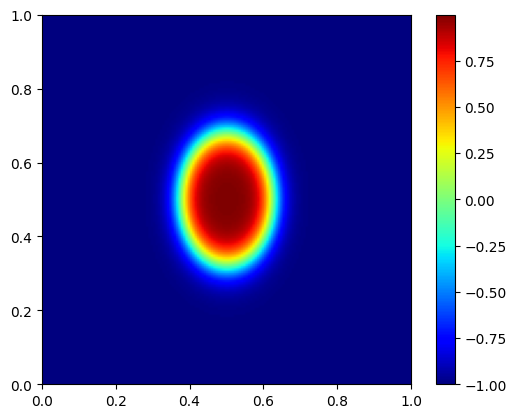

In [27]:
U0 =jax.vmap(jax.vmap(u_init))(reg_grid)
plt.imshow(U0, extent=[x_lb, x_rb, y_lb, y_ub], cmap='jet')
plt.colorbar()

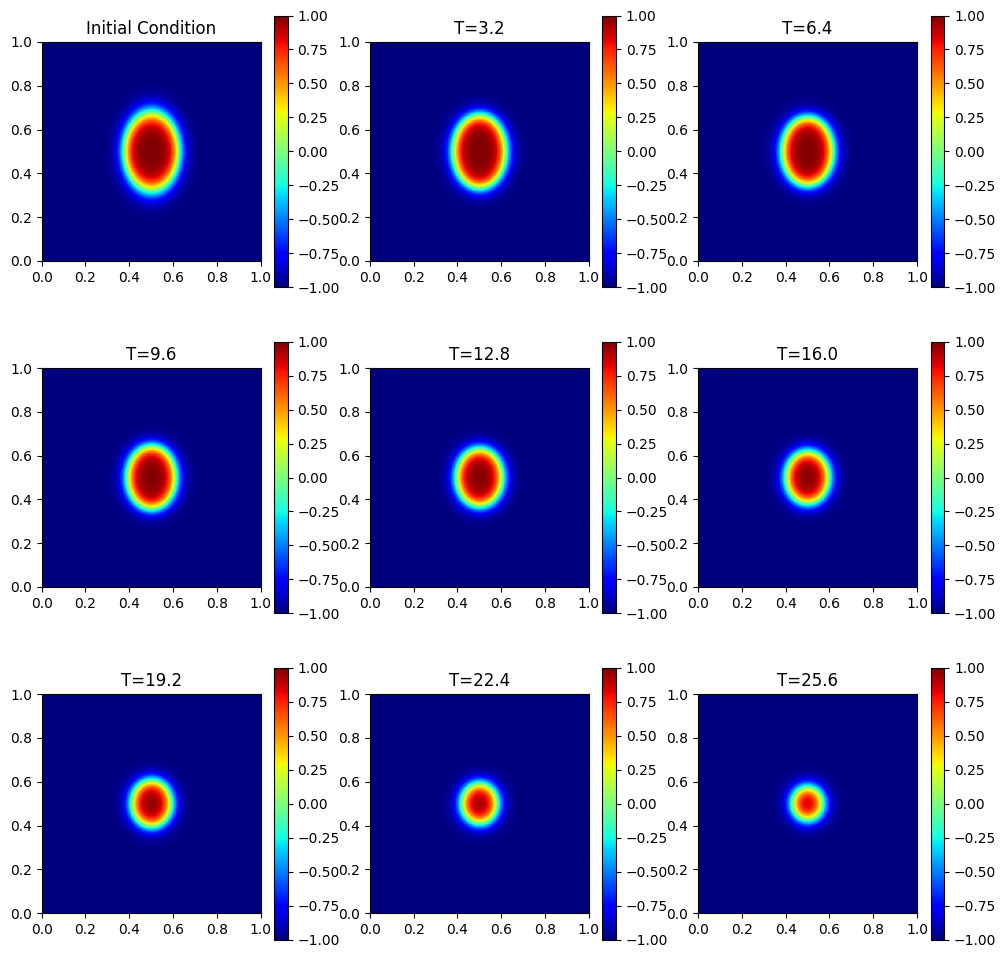

In [ ]:
from utils.helper import splitting_next
spectral_solver = eqx.filter_jit(partial(splitting_next, N_x=N_x, N_y=N_y, dx=dx, eps=eps))
U = U0 
step = 8
plt.figure(figsize=(12, 12))
plt.subplot(3, 3, 1)
plt.imshow(U, extent=[x_lb, x_rb, y_lb, y_ub], cmap='jet',vmin=-1,vmax=1)
plt.colorbar()
plt.title("Initial Condition")
for i in range(8):
    plt.subplot(3, 3, i+2)
    for _ in range(step):
        U = spectral_solver(U, dt=dt)
    t_i = step*dt*(i+1)
    plt.title(f"T={t_i:.1f}")
    plt.imshow(U, extent=[x_lb, x_rb, y_lb, y_ub], cmap='jet', vmin=-1, vmax=1)
    plt.colorbar()



### Define Loss functions

We define first the residuals (IC, BC, PDE) at **one point**. Then we define the loss function on the colocation points with the help of `jax.vmap`:

In [29]:
def res_PDE(u, point_PDE): 
    u_val = u(point_PDE)
    u_t = jax.grad(u)(point_PDE)[0]
    u_x = jax.grad(u)(point_PDE)[1]
    u_xx = jax.grad(lambda x: jax.grad(u)(x)[1])(point_PDE)[1]
    u_yy = jax.grad(lambda x: jax.grad(u)(x)[2])(point_PDE)[2]

    res_PDE = (u_t - (((eps**2)*(u_xx + u_yy) + 1.*(u_val- u_val**3))))
    #res_PDE = (u_t - (((u_xx + u_yy) + 1/(eps**2)*(u_val- u_val**3))))

    return res_PDE
def res_IC(u, point_IC): 
    u_val = u(point_IC)
    u_IC = u_init(point_IC)
    return u_val - u_IC


def res_BC(u, point_BC):
    u_val = u(point_BC)
    return u_val - (-1)

res_PDE_vec = jax.vmap(
    jax.vmap(res_PDE, in_axes=(None,0)), in_axes=(None, 0)
)

@eqx.filter_jit
def residus_and_weights(u, points_PDE, eps_causal=100):
    M = jnp.tril(jnp.ones((N_t, N_t)), k =-1) # Low triangle Matrice
    r_PDE = res_PDE_vec(u, points_PDE)
    L_t = jnp.mean(r_PDE**2, axis=-1)
    W = jax.lax.stop_gradient(jnp.exp(- eps_causal * (M @ L_t)))
    return L_t, W

In [30]:
# Jit the loss function to accelerate the training process !
@eqx.filter_jit
def loss(u, points_Int, points_IC, points_BC):
    r_PDE = jax.vmap(res_PDE, in_axes=(None, 0))(u, points_Int)
    loss_PDE = (r_PDE**2).mean()

    r_IC = jax.vmap(res_IC , in_axes=(None, 0))(u, points_IC)
    loss_IC =(r_IC**2).mean()

    (points_left, points_right, points_top, points_bottom) = points_BC
    loss_bc_x = jnp.mean((jax.vmap(model)(points_left) - jax.vmap(model)(points_right)) ** 2)
    loss_bc_y = jnp.mean((jax.vmap(model)(points_bottom) - jax.vmap(model)(points_top)) ** 2)
    loss_BC = loss_bc_x + loss_bc_y

    return loss_PDE + lambda_IC * loss_IC + lambda_BC*loss_BC

@eqx.filter_jit
def causality_loss(model, points_PDE, points_IC, points_BC, eps_causal=100):
    # 1. Compute initial condition & boundary losses
    r_IC = jax.vmap(res_IC, in_axes=(None, 0))(model, points_IC)
    loss_IC = jnp.mean(r_IC**2)

    (points_left, points_right, points_top, points_bottom) = points_BC
    loss_bc_x = jnp.mean((jax.vmap(model)(points_left) - jax.vmap(model)(points_right)) ** 2)
    loss_bc_y = jnp.mean((jax.vmap(model)(points_bottom) - jax.vmap(model)(points_top)) ** 2)
    loss_BC = loss_bc_x + loss_bc_y


    # 2. Weighted PDE loss
    L_t, W = residus_and_weights(model, points_PDE, eps_causal=eps_causal)
    loss_PDE = jnp.mean(W*L_t)


    return loss_PDE + lambda_IC * loss_IC + lambda_BC * loss_BC

## Retain–Resample–Release (R3) Sampling in PINNs

Physics-Informed Neural Networks (PINNs) can suffer from **propagation failures**, where the network learns the solution well in certain regions but fails to propagate accuracy across the full spatiotemporal domain. This often happens in time-dependent PDEs, where later time steps inherit and amplify earlier errors.

To address this, the **Retain–Resample–Release (R3) sampling** strategy was introduced in  
**"Mitigating Propagation Failures in Physics-Informed Neural Networks using Retain–Resample–Release (R3) Sampling"**.

### Core Idea
R3 improves sampling efficiency by dynamically managing the collocation points during training:
1. **Retain**: Keep a subset of previously sampled points where the PDE residual is still high, ensuring persistent attention to difficult regions.  
2. **Resample**: Replace some points with newly sampled ones (e.g., via Latin Hypercube or uniform sampling) to maintain exploration of the domain.  
3. **Release**: Remove points that are consistently well satisfied (low residual), freeing capacity for harder regions.  

### Advantages
- Prevents the network from forgetting challenging regions.  
- Mitigates error propagation in time-dependent PDEs.  
- Balances **exploitation** (focus on difficult points) and **exploration** (cover the full domain).  
- Provides a more stable and accurate training process compared to static or naive resampling.  

### Reference
- [Mitigating Propagation Failures in Physics-Informed Neural Networks using Retain–Resample–Release (R3) Sampling](https://arxiv.org/abs/2207.02338)  

In [31]:
def r3_sampling(u, key, points_PDE, points_IC):
    key, pde_key, ic_key = jr.split(key, 3)
    N_t, N_p, _ = points_PDE.shape

    # 1. Evaluate PDE residuals across time slices using double vmap -> Shape: (N_t, N_p)
    r_PDE = jax.vmap(jax.vmap(res_PDE, in_axes=(None, 0)), in_axes=(None, 0))(u, points_PDE)

    # Split PRNG keys for each time slice
    time_keys = jr.split(pde_key, N_t)
    
    # 2. Apply R3 resampling independently per time slice
    resampled_PDE_slices = []
    for i in range(N_t):
        pts_i = points_PDE[i]          # Shape: (N_p, 3)
        r_i = r_PDE[i]                 # Shape: (N_p,)
        t_val = pts_i[0, 0]            # Fixed time step for slice i
        
        # Retain points with above-average residual
        threshold_i = jnp.abs(r_i).mean()
        retained_pts = pts_i[jnp.abs(r_i) >= threshold_i]
        
        # Resample new uniform spatial points (x, y) to maintain N_p points total
        n_retained = retained_pts.shape[0]
        n_new = N_p - n_retained
        
        new_spatial = jr.uniform(time_keys[i], (n_new, 2))  # (x, y) in [0, 1]^2
        new_t = jnp.full((n_new, 1), t_val)                 # Attach fixed t_val
        new_pts = jnp.hstack([new_t, new_spatial])
        
        # Combine retained and new points for time slice i
        resampled_slice = jnp.vstack([retained_pts, new_pts])
        resampled_PDE_slices.append(resampled_slice)
        
    # Stack slices back into (N_t, N_p, 3) shape
    resampling_PDE = jnp.stack(resampled_PDE_slices, axis=0)

    # 3. Resample Initial Condition (IC) points -> Shape: (n_IC, 3)
    n_IC = points_IC.shape[0]
    r_IC = jax.vmap(res_IC, in_axes=(None, 0))(u, points_IC)
    threshold_IC = jnp.abs(r_IC).mean() 
    
    r3_points_IC = points_IC[jnp.abs(r_IC) >= threshold_IC]
    n_r3IC = r3_points_IC.shape[0]
    
    new_spatial_IC = jr.uniform(ic_key, (n_IC - n_r3IC, 2))
    t_init_IC = jnp.zeros((n_IC - n_r3IC, 1))
    new_points_IC = jnp.hstack([t_init_IC, new_spatial_IC])
    resampling_IC = jnp.vstack([r3_points_IC, new_points_IC])

    return resampling_PDE, resampling_IC

## Define the Optimizer and Step Functions

In this section, we set up the optimizer using **Optax**, a gradient processing and optimization library for JAX.  
The optimizer is responsible for updating the trainable parameters of our neural network during training.  
We then define a **step function**, which performs a single iteration of the training loop: it computes the loss, evaluates gradients, and applies the parameter updates using the chosen optimizer.


In [32]:
optimizer = optax.adam(lr)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))


@eqx.filter_jit
def step(model, opt_state, points_PDE, points_IC, points_BC, loss_fn):
    total_loss, grads = eqx.filter_value_and_grad(loss_fn)(model, points_PDE, points_IC, points_BC)
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model= eqx.apply_updates(model, updates)
    return model, opt_state, total_loss



In [33]:
loss_history = []
pbar = trange(n_epochs)
best = 1e9
for epoch in pbar:

    model_new, opt_state, total_loss = step(
        model, opt_state, 
        points_PDE=points_PDE, points_IC=points_IC,
        points_BC=points_BC, loss_fn = causality_loss
        )
    if total_loss < best:
        best = total_loss 
        best_model = model
        epoch_best = epoch
    model = model_new
    loss_history.append(total_loss)

    if  (epoch+1) % (n_epochs // 200) == 0:
        key, r3key =jr.split(key)
        points_PDE, points_IC = r3_sampling(
            model, r3key, 
            points_PDE=points_PDE, points_IC = points_IC
        )


    if (epoch == 0) or (epoch+1) % (n_epochs//20) == 0:
        pbar.set_postfix({"Epoch": epoch, "loss": total_loss})

model = best_model
# save best model
eqx.tree_serialise_leaves("pinns-2d-allen-cahn.eqx", best_model)

100%|██████████| 1000/1000 [02:16<00:00,  7.32it/s, Epoch=999, loss=0.81392735]


Plot the **loss history**

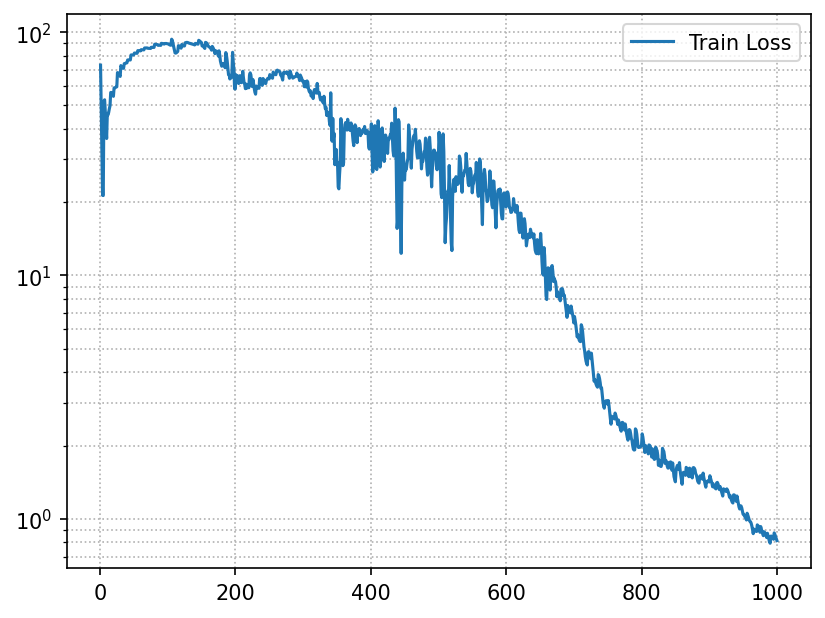

In [34]:
plt.figure(dpi=150)
plt.grid(True, which="both", ls=":")
plt.plot(jnp.arange(1, len(loss_history) + 1), (loss_history), label="Train Loss")
plt.yscale("log")
plt.legend()

## Visualization

Compare the initial colocation points and the ones with R3 sampling 

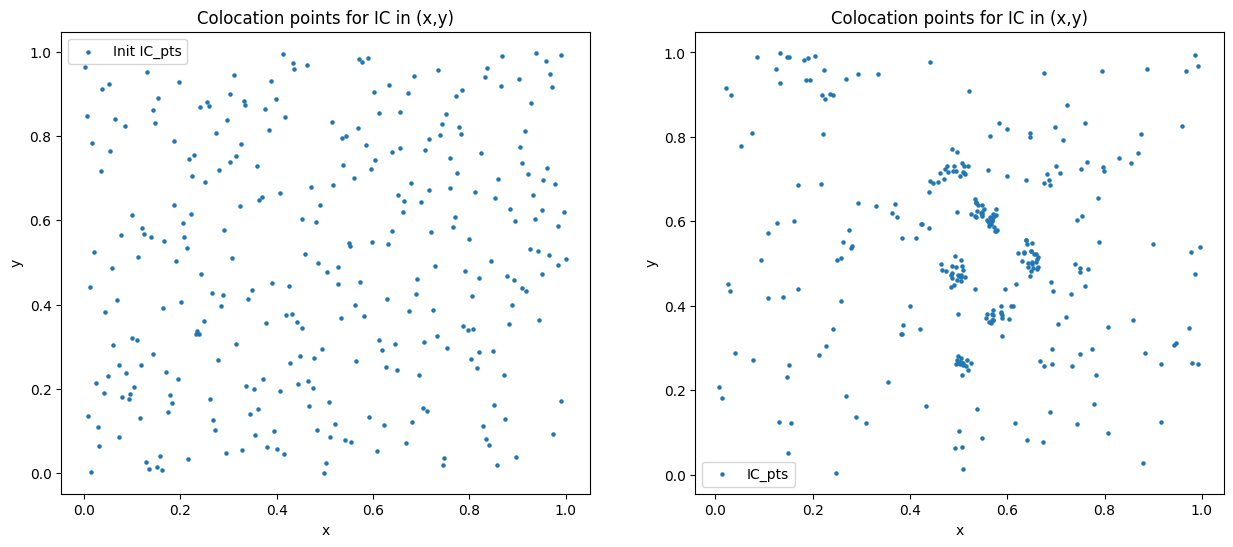

In [35]:
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
plt.scatter(points_IC_init[:, 1], points_IC_init[:, 2], s=5, label="Init IC_pts")
plt.xlabel("x"); plt.ylabel("y"); plt.title("Colocation points for IC in (x,y)")
plt.legend()
plt.subplot(1,2,2)
plt.scatter(points_IC[:, 1], points_IC[:, 2], s=5, label="IC_pts")
plt.xlabel("x"); plt.ylabel("y"); plt.title("Colocation points for IC in (x,y)")
plt.legend()

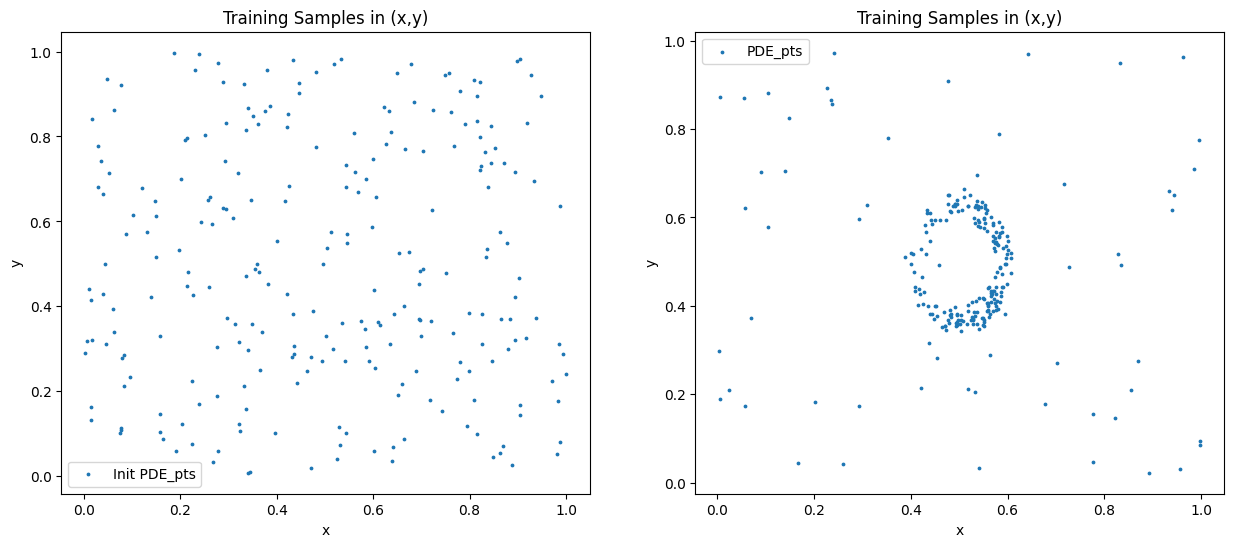

In [36]:
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
plt.scatter(points_PDE_init[1, :, 1], points_PDE_init[1, :, 2], s=3, label="Init PDE_pts")
plt.xlabel("x"); plt.ylabel("y"); plt.title("Training Samples in (x,y)")
plt.legend()
plt.subplot(1,2,2)
plt.scatter(points_PDE[1, :, 1], points_PDE[1, :, 2], s=3, label="PDE_pts")
plt.xlabel("x"); plt.ylabel("y"); plt.title("Training Samples in (x,y)")
plt.legend()

In [37]:
def draw(model, t):
    mesh = jnp.meshgrid(jnp.linspace(x_lb, x_rb, 2*N_x), jnp.linspace(y_lb, y_ub, 2*N_y))
    T = t*jnp.ones_like(mesh[0])
    mesh_with_fixed_time = jnp.stack([T]+mesh, axis=-1)
    u = jax.vmap(jax.vmap(model))(mesh_with_fixed_time)
    plt.imshow(u, extent=[x_lb, x_rb, y_lb, y_ub], cmap='jet', vmin=-1, vmax=1)
    plt.colorbar()
    return u

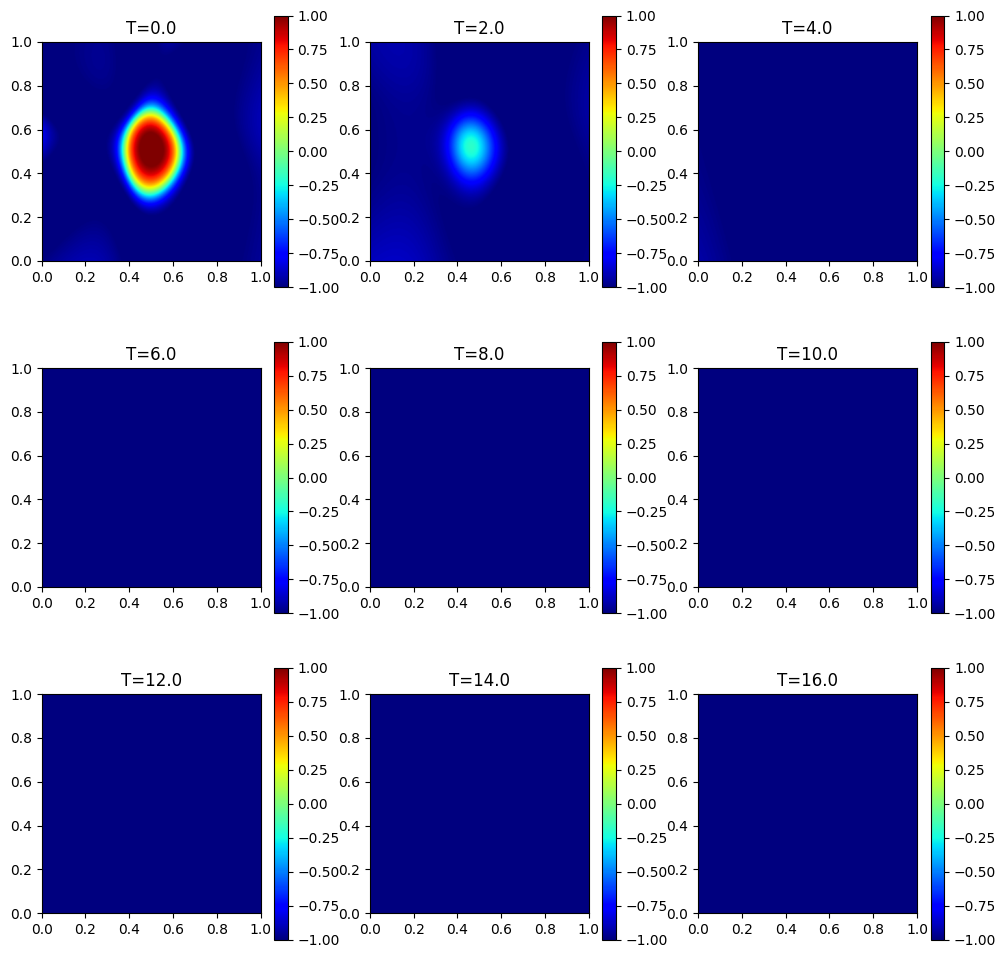

In [38]:
plt.figure(figsize=(12, 12))
plt.subplot(3, 3, 1)
Ts = jnp.linspace(T0, Tf, 9, endpoint=True)
for i, ti in enumerate(Ts):
    plt.subplot(3, 3, i+1)
    t_i = i*Tf/8
    plt.title(f"T={t_i:.1f}")
    draw(model, t_i)



What if you change:  
- `lambda_IC`, `lambda_BC`: the weights on the IC and BC losses  
- The frequency of R3 sampling
- The width and depth of the neural network  
- The learning rate  
- The number of collocation points (interior, IC, BC)  
- The sampling method (Sobol, uniform, etc.)  

You can also try other initial conditions.  
For instance, consider a perturbed disk using

In [39]:
#
#def generate_perturbed_circle(key, mode_st = 5, mode=6 , R = 0.2, perp = 0.1):
#    def theta(x, y): 
#        e1 = jnp.array([1. , 0.])
#        norm = jnp.where((x-0.5)**2 + (y-0.5)**2 >0, jnp.sqrt((x-0.5)**2 + (y-0.5)**2), 1.) 
#        v1 = jnp.stack([(x-0.5)/norm, (y-0.5)/norm], axis=-1) 
#        return  jnp.where(v1[..., 1] >=0, 
#                         jnp.arccos(jnp.clip(jnp.dot(v1, e1), -1.0, 1.0)),  
#                         2*jnp.pi - jnp.arccos(jnp.clip(jnp.dot(v1, e1), -1.0, 1.0)),
#        )
#    def generate_fourier(key, mode):
#        key, coskey, sinkey = jax.random.split(key, 3)
#        a = jax.random.normal(coskey, (mode - mode_st + 1,))
#        b = jax.random.normal(sinkey, (mode - mode_st + 1, ))
#        a  = a.at[:].divide((jnp.linalg.norm(a, 2)+ jnp.linalg.norm(b, 2)))
#        b  = b.at[:].divide((jnp.linalg.norm(a, 2)+ jnp.linalg.norm(b, 2)))
#
#        def fourier(t): 
#            kt = t*jnp.arange(mode_st, mode+1)
#            value = a @ jnp.cos(kt) + b @ jnp.sin(kt)
#            return value 
#        return fourier 
#
#    fourier = generate_fourier(key, mode)
#    key, rkey, rperpkey, centrekey = jax.random.split(key, 4)
#    r = jax.random.uniform(rkey, minval=0.6*R, maxval=1.5*R)
#    r_perp = jax.random.uniform(rperpkey, minval= (0.2-perp)*r, maxval=(0.4+perp)*r)
#    c = jax.random.uniform(centrekey, shape=(2,), minval=-0.4*r, maxval=0.4*r)
#
#
#    #@partial(jax.vmap, in_axes=(0, 0))
#    #@partial(jax.vmap, in_axes=(0, 0))
#    def f_perb(z):
#        x, y = z[1], z[2]
#        r_p = r + r_perp*fourier(theta(x, y))
#        return jnp.tanh( (r_p- jnp.sqrt( (x - 0.5-c[0])**2 + (y - 0.5-c[1])**2))/jnp.sqrt(2*eps**2))
#
#    return f_perb
#
#key, fourier_key = jax.random.split(key)
#u_init = generate_perturbed_circle(fourier_key, mode =6)
#
#mesh = jnp.meshgrid(jnp.linspace(x_lb, x_rb, 100), jnp.linspace(y_lb, y_ub, 100))
#T = 0*jnp.ones_like(mesh[0])
#mesh_with_fixed_time = jnp.stack([T]+mesh, axis=-1)
#plt.imshow(jax.vmap(jax.vmap(u_init))(mesh_with_fixed_time), extent=[x_lb, x_rb, y_lb, y_ub], cmap='rainbow')
#plt.colorbar()

# Causality (Advanced)

#  Causality-Conforming Loss Function
 Enforces temporal sequentiality by weighting PDE residuals at time t_i based on the accumulated error from all preceding time steps t_j (j < i).

In [40]:
@eqx.filter_jit
def causality_loss(model, points_PDE, points_IC, points_BC, eps_causal=10.0):
    # 1. Compute initial condition & boundary losses
    r_IC = jax.vmap(res_IC, in_axes=(None, 0))(model, points_IC)
    loss_IC = jnp.mean(r_IC**2)

    (points_left, points_right, points_top, points_bottom) = points_BC
    loss_bc_x = jnp.mean((jax.vmap(model)(points_left) - jax.vmap(model)(points_right)) ** 2)
    loss_bc_y = jnp.mean((jax.vmap(model)(points_bottom) - jax.vmap(model)(points_top)) ** 2)
    loss_BC = loss_bc_x + loss_bc_y

    # 2. Sort PDE collocation points chronologically by time (t)
    t_coords = points_PDE[:, 0]
    sort_idx = jnp.argsort(t_coords)
    sorted_points_PDE = points_PDE[sort_idx]

    # 3. Compute point-wise PDE residuals in time order
    r_PDE = jax.vmap(res_PDE, in_axes=(None, 0))(model, sorted_points_PDE)
    r_PDE_sq = r_PDE**2

    # 4. Compute causal weights: w_i = exp(-eps * sum_{j < i} L_PDE(t_j))
    # Cumulative sum of previous losses (excluding current step)
    cum_loss = jnp.cumsum(r_PDE_sq) - r_PDE_sq
    weights = jax.lax.stop_gradient(jnp.exp(-eps_causal * cum_loss))

    # 5. Weighted PDE loss
    loss_PDE = jnp.mean(weights * r_PDE_sq)

    return loss_PDE + lambda_IC * loss_IC + lambda_BC * loss_BC

In [41]:
# def r3_resampling(u, key): 
#     r_PDE = abs(residu_PDE(u, ts, coloc_x, coloc_y))
#     mean_PDE = jnp.mean(r_PDE, axis=-1)
#     key, *subkeys = jr.split(key, N_t+1)
#     new_coloc_x = jnp.zeros((0, N_x*N_y))
#     new_coloc_y = jnp.zeros((0, N_x*N_y))
#     for i in range(N_t):
#         idx_i = jnp.nonzero( (r_PDE[i] >= mean_PDE[i]))
#         old_coloc_x_i = coloc_x[i, idx_i]
#         old_coloc_y_i = coloc_y[i, idx_i]
#         n_old_i = idx_i[0].shape[0]
#         new_coloc_i = jr.uniform(subkeys[i], shape=(1, N_x*N_y -  n_old_i, 2)) 
#         new_coloc_x_i = jnp.concat([old_coloc_x_i, new_coloc_i[..., 0]], axis=-1)
#         new_coloc_y_i = jnp.concat([old_coloc_y_i, new_coloc_i[..., 1]], axis=-1)
#         new_coloc_x = jnp.concat([new_coloc_x, new_coloc_x_i], axis=0)
#         new_coloc_y = jnp.concat([new_coloc_y, new_coloc_y_i], axis=0)
#     return new_coloc_x, new_coloc_y
#         
# 
# for tol in tol_list:
#     pbar = trange(n_epoch, dynamic_ncols=True, file=sys.stdout)
#     best = 1e9
#     for epoch in pbar:
# 
#         if  (epoch <=3/4*n_epoch):
#             model, opt_state, weighted_loss = step(model, opt_state, tol)
#             if epoch % (n_epoch//6) == 0: 
#                 key, r3key = jr.split(key)
#                 coloc_x, coloc_y = r3_resampling(model, r3key)
#         else: 
#             model_new, opt_state, weighted_loss = step(model, opt_state, tol)
#             if weighted_loss < best: 
#                 best_model = model
#                 best_epoch = epoch
#                 best = weighted_loss
#             model = model_new
# 
# 
#         loss_history.append(weighted_loss)
# 
#         # Logging
#         if (epoch +1) % 1000 == 0:
#             #print(f"Epoch={epoch}, loss={loss}, tol={tol}")
#             L_t, W = residus_and_weights(model, tol)
#             pbar.set_postfix({"Epoch" : epoch , 'Loss': weighted_loss, 'tol': tol,}) 
#             if min(W) >=0.99:
#                 break
#         if epoch == n_epoch -1: 
#             model = best_model
#             pbar.set_postfix({"Epoch" : epoch , 'Loss': weighted_loss, 'tol': tol,}) 
#         

# Fourier Neural Operator (FNO)

<img src="FNO-illustration.png" width="800">

Build a neural operator surrogate maping initial condition to next time step solution 
$$
\mathcal{G}_\theta : u_0(\cdot) \mapsto u(t=dt, \cdot)
$$